# Assignment 04: Object Detection, Semantic Segmentation, and Face Recognition

**Student Name:** [Muner Nurkaussar]

**Student ID:** [S23067429]

---

## Setup

Install the required libraries:

In [ ]:
# Uncomment and run to install dependencies
!pip install ultralytics deepface torch torchvision matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.0 MB/s eta 0:00:00


In [12]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu


---
## Part 1: Transpose Convolution (Paper Calculation)

**Complete the manual calculation on paper and attach a photo/scan here.**

Given:
- Input (2×2): `[[2, 1], [3, 2]]`
- Filter (3×3): all ones
- Stride: 2, Padding: 1

Calculate the output size and resulting matrix.

### Your Answer:

**Output size calculation:**

[Write your calculation here]

**Output matrix:**

[Write or attach your answer here]

---
## Part 2: Object Detection with YOLO

### 2.1 Basic Object Detection

In [13]:
from ultralytics import YOLO
import cv2

# Load pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')

In [18]:
!wget https://raw.githubusercontent.com/nurkausarmuner-enka/assignment-04-object-detection/master/1280px-Golden_tabby_and_white_kitten_n01.jpg

--2026-03-18 01:53:03--  https://raw.githubusercontent.com/nurkausarmuner-enka/assignment-04-object-detection/master/1280px-Golden_tabby_and_white_kitten_n01.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134485 (131K) [image/jpeg]
Saving to: ‘1280px-Golden_tabby_and_white_kitten_n01.jpg’

1280px-Golden_tabby 100%[===================>] 131.33K  --.-KB/s    in 0.004s  

2026-03-18 01:53:03 (32.1 MB/s) - ‘1280px-Golden_tabby_and_white_kitten_n01.jpg’ saved [134485/134485]




0: 448x640 1 cat, 326.4ms
Speed: 22.4ms preprocess, 326.4ms inference, 36.1ms postprocess per image at shape (1, 3, 448, 640)


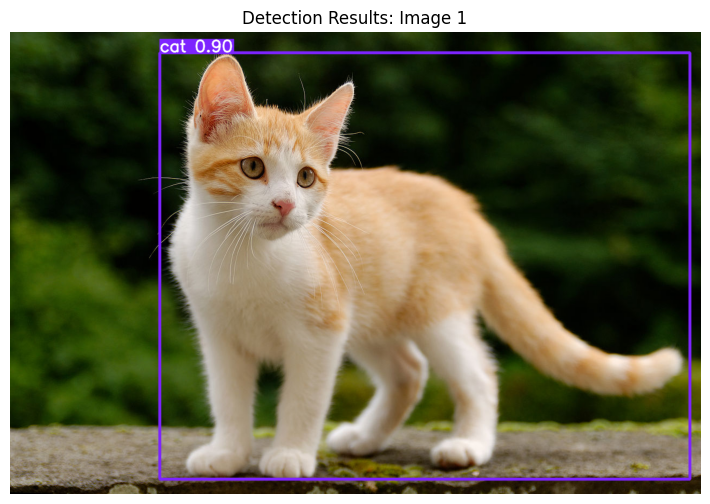

In [19]:
# TODO: Run detection on your images
# Download or use your own images
image_paths = ['1280px-Golden_tabby_and_white_kitten_n01.jpg']
results = model(image_paths)

for i, result in enumerate(results):
    res_plotted = result.plot()  # This draws the boxes on the image
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(res_rgb)
    plt.title(f"Detection Results: Image {i+1}")
    plt.axis('off')
    plt.show()

In [20]:
# TODO: Print detected objects with confidence scores and bounding boxes
for i, result in enumerate(results):
    print(f"\n--- DETECTIONS FOR IMAGE {i+1} ---")
    boxes = result.boxes
    print(f"Detected {len(boxes)} objects:")

    for box in boxes:
        # 1. Get Class Name
        class_id = int(box.cls[0])
        label = model.names[class_id]

        # 2. Get Confidence Score
        conf = box.conf[0].item()

        # 3. Get Bounding Box Coordinates in xywh format (normalized or pixels)
        # xywh[0] contains [x_center, y_center, width, height]
        coords = box.xywh[0].tolist()

        print(f" - Object: {label:10} | Conf: {conf:.2f} | Box (xywh): {coords}")


--- DETECTIONS FOR IMAGE 1 ---
Detected 1 objects:
 - Object: cat        | Conf: 0.90 | Box (xywh): [768.5822143554688, 434.2231750488281, 981.3712158203125, 791.0023803710938]


### 2.2 Understanding YOLO Output

**Answer the following questions:**

1. What does the confidence score represent?

   [Your answer]

2. How are bounding box coordinates normalized?

   [Your answer]

3. What is the difference between `xyxy` and `xywh` format?

   [Your answer]

### 2.3 Non-Max Suppression Experiments

In [ ]:
# TODO: Test different confidence thresholds
# results_conf_25 = model('image.jpg', conf=0.25)
# results_conf_50 = model('image.jpg', conf=0.50)
# results_conf_75 = model('image.jpg', conf=0.75)

# Compare and visualize results

In [ ]:
# TODO: Test different IoU thresholds
# results_iou_30 = model('image.jpg', iou=0.3)
# results_iou_50 = model('image.jpg', iou=0.5)
# results_iou_70 = model('image.jpg', iou=0.7)

# Compare and visualize results

**Analysis:** Explain what happens when you change these thresholds.

[Your analysis]

---
## Part 3: Face Recognition with DeepFace

### 3.1 Face Verification

In [ ]:
from deepface import DeepFace

In [ ]:
# TODO: Test face verification with same-person pairs
# result = DeepFace.verify(img1_path="person_a_1.jpg", img2_path="person_a_2.jpg")
# print(result)

In [ ]:
# TODO: Test face verification with different-person pairs
# result = DeepFace.verify(img1_path="person_a_1.jpg", img2_path="person_b_1.jpg")
# print(result)

**Report your results:**

| Pair | Verified | Distance | Threshold |
|------|----------|----------|----------|
| Person A photo 1 vs 2 | | | |
| Person A photo 1 vs Person B photo 1 | | | |

### 3.2 Face Analysis

In [ ]:
# TODO: Analyze facial attributes
# analysis = DeepFace.analyze(img_path="face.jpg", actions=['age', 'gender', 'emotion'])
# print(analysis)

**Discussion:** Were the predictions accurate? Why or why not?

[Your discussion]

### 3.3 Face Embeddings

In [ ]:
# TODO: Extract and compare face embeddings
# embedding1 = DeepFace.represent(img_path="face1.jpg", model_name="Facenet")
# embedding2 = DeepFace.represent(img_path="face2.jpg", model_name="Facenet")

# Calculate Euclidean distance
# import numpy as np
# distance = np.linalg.norm(np.array(embedding1[0]['embedding']) - np.array(embedding2[0]['embedding']))
# print(f"Euclidean distance: {distance}")

---
## Part 4: U-Net Architecture

### 4.1 Architecture Diagram

**Attach your hand-drawn or digital diagram here.**

[Insert image or describe your diagram]

### 4.2 Skip Connections Questions

1. What is the purpose of skip connections in U-Net?

   [Your answer]

2. How do skip connections help with information loss?

   [Your answer]

3. What operation combines encoder and decoder features?

   [Your answer]

### 4.3 U-Net Implementation

In [ ]:
class DoubleConv(nn.Module):
    """Two consecutive Conv-BatchNorm-ReLU blocks"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # TODO: Implement two 3x3 convolutions with BatchNorm and ReLU
        self.double_conv = nn.Sequential(
            # Your code here
        )

    def forward(self, x):
        return self.double_conv(x)

In [ ]:
class DownBlock(nn.Module):
    """Downsampling block: MaxPool + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # TODO: Implement maxpool followed by double convolution
        pass

    def forward(self, x):
        pass

In [ ]:
class UpBlock(nn.Module):
    """Upsampling block: TransposeConv + Concatenate + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # TODO: Implement transpose convolution for upsampling
        # Then concatenate with skip connection and apply double convolution
        pass

    def forward(self, x, skip):
        pass

In [ ]:
# TODO: Test your implementations
# double_conv = DoubleConv(3, 64)
# test_input = torch.randn(1, 3, 256, 256)
# output = double_conv(test_input)
# print(f"Input shape: {test_input.shape}, Output shape: {output.shape}")

---
## Part 5: Questions for Understanding

### Object Detection

**1. YOLO vs Sliding Window:** Why is YOLO much faster than traditional sliding window approaches?

[Your answer]

**2. Anchor Boxes:** What problem do anchor boxes solve?

[Your answer]

**3. IoU:** Write the formula for IoU and explain the 0.5 threshold.

[Your answer]

**4. Bounding Box Regression:** How are bounding box coordinates encoded in YOLO?

[Your answer]

### Semantic Segmentation

**5. Classification vs Segmentation:** What is the key difference?

[Your answer]

**6. Transpose Convolution:** Why do we need it in U-Net?

[Your answer]

**7. Per-pixel Classification:** If input is 256×256 with 10 classes, what is the output shape?

[Your answer]

### Face Recognition

**8. Verification vs Recognition:** Explain the difference.

[Your answer]

**9. One-shot Learning:** Why is face recognition a one-shot learning problem?

[Your answer]

**10. Triplet Loss:** What are Anchor, Positive, Negative? Why do we need a margin?

[Your answer]

**11. Siamese Networks:** How do they help with face verification?

[Your answer]